# Phase 4 — Semantic Fusion

**Grid Engine: Variable-Resolution 2.5D Semantic Elevation Grid**

This notebook fuses per-point semantic predictions into per-cell semantic
labels using **confidence-weighted voting**. Multiple points with different
predictions are combined into a single cell-level semantic class.

```
Points in cell:   Road(0.90), Road(0.95), Vehicle(0.92), Vehicle(0.96)
      ↓
score[Road]    = 0.90 + 0.95 = 1.85
score[Vehicle] = 0.92 + 0.96 = 1.88
      ↓
Cell class = Vehicle  (highest score)
Cell confidence = 1.88 / (1.85 + 1.88) = 0.504
```

**Input:** `phase3_output.npz` (cells with elevation + point mapping)

**Output:** `phase4_output.npz` (cells with elevation + semantics)


## 1. Configuration & Data Loading


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import time
import os

# ============================================================
# PHASE 4 — SEMANTIC FUSION
# 19-CLASS CONFIGURATION
# ============================================================

# ── Load Phase 3 output ──────────────────────────────────────
phase3_path = "/kaggle/input/notebooks/avranu01biswas/phase-3/phase3_output.npz"

phase3 = np.load(
    phase3_path,
    allow_pickle=True
)

# ── Extract Phase 3 data ─────────────────────────────────────
points_xyz       = phase3["points_xyz"]
labels           = phase3["labels"].astype(np.int32)
confidence       = phase3["confidence"].astype(np.float64)
intensity        = phase3["intensity"]
radial_distance  = phase3["radial_distance"]
point_to_cell    = phase3["point_to_cell"]
point_resolution = phase3["point_resolution"]
sorted_order     = phase3["sorted_order"]
group_starts     = phase3["group_starts"]
group_ends       = phase3["group_ends"]
cell_data        = phase3["cell_data"]
cell_columns     = list(phase3["cell_columns"])
grid_config      = phase3["grid_config"].item()
metadata         = phase3["metadata"].item()

N_POINTS = points_xyz.shape[0]
n_cells  = cell_data.shape[0]


# ============================================================
# 19-CLASS SEMANTIC LABEL MAPPING
# ============================================================

LABEL_NAMES = {
    0:  "Car",
    1:  "Bicycle",
    2:  "Motorcycle",
    3:  "Truck",
    4:  "Other-vehicle",
    5:  "Person",
    6:  "Bicyclist",
    7:  "Motorcyclist",
    8:  "Road",
    9:  "Parking",
    10: "Sidewalk",
    11: "Other-ground",
    12: "Building",
    13: "Fence",
    14: "Vegetation",
    15: "Trunk",
    16: "Terrain",
    17: "Pole",
    18: "Traffic-sign",
}

# IMPORTANT:
# Must be 19, because label IDs go from 0 to 18.
N_CLASSES = len(LABEL_NAMES)


# ============================================================
# CLASS COLORS
# ============================================================

CLASS_COLORS = {
    0:  "#ff0000",   # Car
    1:  "#ff8000",   # Bicycle
    2:  "#ff8000",   # Motorcycle
    3:  "#800000",   # Truck
    4:  "#800000",   # Other-vehicle
    5:  "#0000ff",   # Person
    6:  "#0000ff",   # Bicyclist
    7:  "#0000ff",   # Motorcyclist
    8:  "#808080",   # Road
    9:  "#606060",   # Parking
    10: "#a0a0a0",   # Sidewalk
    11: "#c0c0c0",   # Other-ground
    12: "#ffd700",   # Building
    13: "#8b4513",   # Fence
    14: "#008000",   # Vegetation
    15: "#8b4513",   # Trunk
    16: "#90ee90",   # Terrain
    17: "#d3d3d3",   # Pole
    18: "#ff00ff",   # Traffic-sign
}


# ============================================================
# SEMANTIC IMPORTANCE PRIORITY
# ============================================================
#
# Higher value = more important for adaptive refinement.
#
# These values are used later in Phase 6.
#

SEMANTIC_PRIORITY = {
    0: 5,    # Car
    1: 5,    # Bicycle
    2: 5,    # Motorcycle
    3: 5,    # Truck
    4: 5,    # Other-vehicle
    5: 5,    # Person
    6: 5,    # Bicyclist
    7: 5,    # Motorcyclist
    8: 1,    # Road
    9: 1,    # Parking
    10: 2,   # Sidewalk
    11: 1,   # Other-ground
    12: 4,   # Building
    13: 4,   # Fence
    14: 2,   # Vegetation
    15: 3,   # Trunk
    16: 1,   # Terrain
    17: 4,   # Pole
    18: 5,   # Traffic-sign
}


# ============================================================
# VALIDATION
# ============================================================

print("=" * 70)
print("PHASE 4 — SEMANTIC FUSION")
print("=" * 70)

print(f"Loaded Phase 3 output:")
print(f"  Points : {N_POINTS:,}")
print(f"  Cells  : {n_cells:,}")

print(f"\nSemantic classes: {N_CLASSES}")

print("\nClass configuration:")
for cls_id in range(N_CLASSES):
    print(
        f"  {cls_id:2d}: "
        f"{LABEL_NAMES[cls_id]:<16} "
        f"priority={SEMANTIC_PRIORITY[cls_id]}"
    )


# ── Check labels ─────────────────────────────────────────────

unique_labels, label_counts = np.unique(
    labels,
    return_counts=True
)

print("\nActual labels present in this frame:")

for label_id, count in zip(unique_labels, label_counts):
    name = LABEL_NAMES.get(
        int(label_id),
        "UNKNOWN"
    )

    print(
        f"  Label {label_id:2d}: "
        f"{name:<16} "
        f"{count:>8,} points"
    )


# ── Check for invalid labels ────────────────────────────────

invalid_labels = unique_labels[
    ~np.isin(
        unique_labels,
        list(LABEL_NAMES.keys())
    )
]

if len(invalid_labels) > 0:
    raise ValueError(
        f"Invalid label IDs found: {invalid_labels}. "
        f"Expected IDs 0–18."
    )

print("\n✓ All label IDs are valid (0–18)")


# ── Check dimensions ─────────────────────────────────────────

if len(labels) != N_POINTS:
    raise ValueError(
        f"Label count ({len(labels)}) does not match "
        f"point count ({N_POINTS})."
    )

if len(confidence) != N_POINTS:
    raise ValueError(
        "Confidence array length does not match "
        "number of points."
    )

if len(point_to_cell) != N_POINTS:
    raise ValueError(
        "point_to_cell length does not match "
        "number of points."
    )

if point_to_cell.min() < 0 or point_to_cell.max() >= n_cells:
    raise ValueError(
        f"Invalid cell indices. "
        f"Range = [{point_to_cell.min()}, "
        f"{point_to_cell.max()}], "
        f"but valid range is [0, {n_cells-1}]."
    )

print("✓ Point/cell dimensions validated")
print("✓ Phase 4 configuration ready")
print("=" * 70)

PHASE 4 — SEMANTIC FUSION
Loaded Phase 3 output:
  Points : 123,389
  Cells  : 51,575

Semantic classes: 19

Class configuration:
   0: Car              priority=5
   1: Bicycle          priority=5
   2: Motorcycle       priority=5
   3: Truck            priority=5
   4: Other-vehicle    priority=5
   5: Person           priority=5
   6: Bicyclist        priority=5
   7: Motorcyclist     priority=5
   8: Road             priority=1
   9: Parking          priority=1
  10: Sidewalk         priority=2
  11: Other-ground     priority=1
  12: Building         priority=4
  13: Fence            priority=4
  14: Vegetation       priority=2
  15: Trunk            priority=3
  16: Terrain          priority=1
  17: Pole             priority=4
  18: Traffic-sign     priority=5

Actual labels present in this frame:
  Label  0: Car                 1,641 points
  Label  4: Other-vehicle          70 points
  Label  6: Bicyclist               3 points
  Label  8: Road               26,972 points
  Labe

## 2. Confidence-Weighted Semantic Voting

For each cell, we accumulate the confidence of every point by its class.
The class with the highest total confidence wins.

This is a simple but effective fusion strategy:
- Handles mixed-class cells (e.g., road + vehicle boundary)
- Weighs confident predictions more heavily
- Naturally handles unequal point counts per class


In [5]:
# ============================================================
# CONFIDENCE-WEIGHTED SEMANTIC VOTING
# ============================================================

t_start = time.time()

# One row per grid cell
# One column per semantic class (0–18)

cell_scores = np.zeros(
    (n_cells, N_CLASSES),
    dtype=np.float64
)

# Accumulate confidence for each
# (cell, semantic class) pair

np.add.at(
    cell_scores,
    (point_to_cell, labels),
    confidence
)

print("✓ Confidence-weighted semantic voting complete")
print(f"  cell_scores shape = {cell_scores.shape}")


# ============================================================
# DETERMINE WINNING CLASS
# ============================================================

cell_semantic_class = np.argmax(
    cell_scores,
    axis=1
).astype(np.int32)


# ============================================================
# SEMANTIC CONFIDENCE
# ============================================================

cell_score_total = cell_scores.sum(axis=1)

cell_winner_score = np.max(
    cell_scores,
    axis=1
)

cell_semantic_confidence = np.divide(
    cell_winner_score,
    cell_score_total,
    out=np.zeros_like(cell_winner_score),
    where=cell_score_total > 0
)


# ============================================================
# SEMANTIC PRIORITY
# ============================================================

priority_lookup = np.array(
    [
        SEMANTIC_PRIORITY[i]
        for i in range(N_CLASSES)
    ],
    dtype=np.float64
)

cell_semantic_priority = priority_lookup[
    cell_semantic_class
]


# ============================================================
# RESULTS
# ============================================================

elapsed = time.time() - t_start

print("\n" + "=" * 70)
print("SEMANTIC FUSION COMPLETE")
print("=" * 70)

print(f"Processing time: {elapsed * 1000:.2f} ms")

print(
    f"Cell score matrix : {cell_scores.shape}"
)

print(
    f"Semantic confidence: "
    f"{cell_semantic_confidence.min():.4f} → "
    f"{cell_semantic_confidence.max():.4f}"
)

print("\nWinning class per cell:")

for cls_id in range(N_CLASSES):

    count = np.sum(
        cell_semantic_class == cls_id
    )

    if count > 0:

        print(
            f"  {cls_id:2d} "
            f"{LABEL_NAMES[cls_id]:<16} "
            f"{count:>8,} cells"
        )

✓ Confidence-weighted semantic voting complete
  cell_scores shape = (51575, 19)

SEMANTIC FUSION COMPLETE
Processing time: 33.73 ms
Cell score matrix : (51575, 19)
Semantic confidence: 0.3129 → 1.0000

Winning class per cell:
   0 Car                   594 cells
   4 Other-vehicle          29 cells
   6 Bicyclist               1 cells
   8 Road               10,671 cells
   9 Parking             2,213 cells
  10 Sidewalk            6,900 cells
  11 Other-ground        1,767 cells
  12 Building              778 cells
  13 Fence                 833 cells
  14 Vegetation         10,273 cells
  15 Trunk                 575 cells
  16 Terrain            16,589 cells
  17 Pole                  274 cells
  18 Traffic-sign           78 cells


## 3. Semantic Statistics


In [6]:
print("=" * 70)
print("SEMANTIC FUSION RESULTS")
print("=" * 70)

print(f"\n{'Class':<14} {'Cells':>7} {'% Cells':>8}  {'Conf min':>9} {'Conf mean':>10} {'Conf max':>9} {'Priority':>9}")
print("-" * 70)

for cls_id in sorted(LABEL_NAMES.keys()):
    mask = (cell_semantic_class == cls_id)
    n_c = mask.sum()
    pct_c = 100.0 * n_c / n_cells

    if n_c > 0:
        conf = cell_semantic_confidence[mask]
        print(f"{cls_id} {LABEL_NAMES[cls_id]:<12s} {n_c:>7} {pct_c:>7.1f}%  "
              f"{conf.min():>9.4f} {conf.mean():>10.4f} {conf.max():>9.4f} "
              f"{SEMANTIC_PRIORITY[cls_id]:>9}")
    else:
        print(f"{cls_id} {LABEL_NAMES[cls_id]:<12s} {n_c:>7} {pct_c:>7.1f}%  "
              f"{'—':>9} {'—':>10} {'—':>9} {SEMANTIC_PRIORITY[cls_id]:>9}")

print(f"\n{'TOTAL':<14} {n_cells:>7}")

# ── Mixed-class cells analysis ──────────────────────────────────
# Cells where the winner confidence is low indicate ambiguous semantics
ambiguous_threshold = 0.6
ambiguous_mask = cell_semantic_confidence < ambiguous_threshold
n_ambiguous = ambiguous_mask.sum()

print(f"\nMixed-class analysis:")
print(f"  Cells with confidence < {ambiguous_threshold}: {n_ambiguous:,} ({100.0*n_ambiguous/n_cells:.1f}%)")
print(f"  These cells have near-equal evidence for multiple classes,")
print(f"  typically at object boundaries (e.g., road/vehicle edge).")

# ── Per-class point-level vs cell-level comparison ──────────────
print(f"\nPoint-level vs cell-level class distribution:")
print(f"{'Class':<14} {'Points':>8} {'% Points':>9}  {'Cells':>7} {'% Cells':>8}")
print("-" * 50)

for cls_id in sorted(LABEL_NAMES.keys()):
    n_pts = (labels == cls_id).sum()
    pct_pts = 100.0 * n_pts / N_POINTS
    n_cells_cls = (cell_semantic_class == cls_id).sum()
    pct_cells = 100.0 * n_cells_cls / n_cells
    print(f"{cls_id} {LABEL_NAMES[cls_id]:<12s} {n_pts:>8} {pct_pts:>8.1f}%  "
          f"{n_cells_cls:>7} {pct_cells:>7.1f}%")

SEMANTIC FUSION RESULTS

Class            Cells  % Cells   Conf min  Conf mean  Conf max  Priority
----------------------------------------------------------------------
0 Car              594     1.2%     0.5012     0.9816    1.0000         5
1 Bicycle            0     0.0%          —          —         —         5
2 Motorcycle         0     0.0%          —          —         —         5
3 Truck              0     0.0%          —          —         —         5
4 Other-vehicle      29     0.1%     0.5712     0.9521    1.0000         5
5 Person             0     0.0%          —          —         —         5
6 Bicyclist          1     0.0%     0.7916     0.7916    0.7916         5
7 Motorcyclist       0     0.0%          —          —         —         5
8 Road           10671    20.7%     0.5000     0.9917    1.0000         1
9 Parking         2213     4.3%     0.5000     0.9832    1.0000         1
10 Sidewalk        6900    13.4%     0.4058     0.9885    1.0000         2
11 Other-groun

## 4. Extend Cell Data with Semantics


In [7]:
# ── Add semantic columns to cell_data ────────────────────────────
# New columns:
# 12: semantic_class       — winning class ID
# 13: semantic_confidence   — winner_score / total_score
# 14: semantic_priority     — importance level for refinement

new_columns = ["semantic_class", "semantic_confidence", "semantic_priority"]

cell_data_extended = np.column_stack([
    cell_data,
    cell_semantic_class.astype(np.float64),
    cell_semantic_confidence,
    cell_semantic_priority.astype(np.float64),
])

cell_columns_extended = cell_columns + new_columns

print(f"Extended cell data: {cell_data_extended.shape}  ({len(cell_columns_extended)} columns)")
print(f"  New columns: {new_columns}")
print(f"  All columns: {cell_columns_extended}")
print(f"  Memory: {cell_data_extended.nbytes / 1024:.1f} KB")

Extended cell data: (51575, 15)  (15 columns)
  New columns: ['semantic_class', 'semantic_confidence', 'semantic_priority']
  All columns: [np.str_('x_min'), np.str_('y_min'), np.str_('x_max'), np.str_('y_max'), np.str_('resolution'), np.str_('point_count'), np.str_('elevation'), np.str_('min_height'), np.str_('max_height'), np.str_('height_variance'), np.str_('height_range'), np.str_('occupancy'), 'semantic_class', 'semantic_confidence', 'semantic_priority']
  Memory: 6043.9 KB


## 5. Validation


In [8]:
print("=" * 60)
print("SEMANTIC FUSION VALIDATION")
print("=" * 60)

all_passed = True

# ── Check 1: Every cell has a semantic class ─────────────────────
valid_classes = np.all((cell_semantic_class >= 0) & (cell_semantic_class < N_CLASSES))
if valid_classes:
    print(f"[PASS] All cells have valid semantic class (0..{N_CLASSES-1})")
else:
    print(f"[FAIL] Invalid semantic classes found")
    all_passed = False

# ── Check 2: Confidence is in [0, 1] ────────────────────────────
conf_valid = np.all((cell_semantic_confidence >= 0) & (cell_semantic_confidence <= 1.0 + 1e-10))
if conf_valid:
    print(f"[PASS] All semantic confidences in [0, 1]")
else:
    print(f"[FAIL] Semantic confidence out of range")
    all_passed = False

# ── Check 3: Score totals match point confidences ────────────────
# Total score across all cells and classes should equal sum of all point confidences
total_cell_scores = cell_scores.sum()
total_point_conf = confidence.astype(np.float64).sum()
score_diff = abs(total_cell_scores - total_point_conf)

if score_diff < 1e-3:
    print(f"[PASS] Total scores match: cells={total_cell_scores:.4f}, points={total_point_conf:.4f} (diff={score_diff:.6f})")
else:
    print(f"[FAIL] Score mismatch: cells={total_cell_scores:.4f}, points={total_point_conf:.4f}")
    all_passed = False

# ── Check 4: Winner score <= total score for every cell ──────────
winner_valid = np.all(cell_winner_score <= cell_score_total + 1e-10)
if winner_valid:
    print(f"[PASS] Winner score <= total score for all cells")
else:
    print(f"[FAIL] Some cells have winner score > total score")
    all_passed = False

# ── Check 5: Priority mapping consistency ────────────────────────
expected_priorities = priority_lookup[cell_semantic_class]
priority_match = np.array_equal(cell_semantic_priority, expected_priorities)
if priority_match:
    print(f"[PASS] Semantic priority consistent with class-to-priority mapping")
else:
    print(f"[FAIL] Priority mapping inconsistency")
    all_passed = False

# ── Check 6: No cells with zero total score ─────────────────────
zero_score = (cell_score_total == 0).sum()
if zero_score == 0:
    print(f"[PASS] No cells with zero total score (all cells have evidence)")
else:
    print(f"[FAIL] {zero_score} cells with zero score")
    all_passed = False

print("\n" + "=" * 60)
if all_passed:
    print("ALL SEMANTIC FUSION CHECKS PASSED")
else:
    print("SOME CHECKS FAILED")
print("=" * 60)

SEMANTIC FUSION VALIDATION
[PASS] All cells have valid semantic class (0..18)
[PASS] All semantic confidences in [0, 1]
[PASS] Total scores match: cells=29757.7663, points=29757.7663 (diff=0.000000)
[PASS] Winner score <= total score for all cells
[PASS] Semantic priority consistent with class-to-priority mapping
[PASS] No cells with zero total score (all cells have evidence)

ALL SEMANTIC FUSION CHECKS PASSED


## 6. Visualizations


### 6.1 — Semantic Class Map (Top-Down View)

The core semantic output: each cell colored by its fused semantic class.


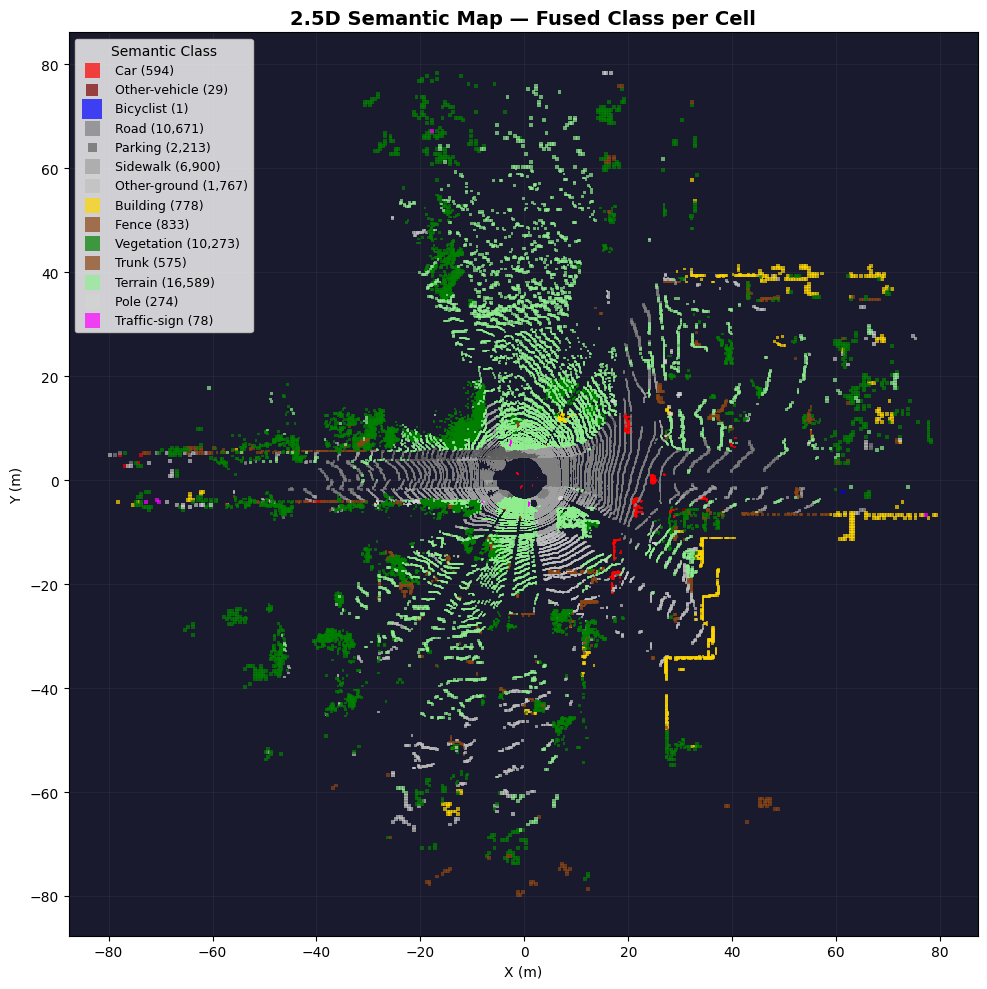

Saved: vis_14_semantic_map.png


In [9]:
fig, ax = plt.subplots(figsize=(16, 10))

cell_cx = (cell_data[:, 0] + cell_data[:, 2]) / 2
cell_cy = (cell_data[:, 1] + cell_data[:, 3]) / 2
cell_res = cell_data[:, 4]
sizes = (cell_res / cell_res.max()) * 8

# Draw each class separately for legend
for cls_id in sorted(LABEL_NAMES.keys()):
    mask = (cell_semantic_class == cls_id)
    if mask.sum() == 0:
        continue
    ax.scatter(
        cell_cx[mask], cell_cy[mask],
        c=CLASS_COLORS[cls_id],
        s=sizes[mask], marker='s', alpha=0.7, edgecolors='none',
        label=f"{LABEL_NAMES[cls_id]} ({mask.sum():,})"
    )

ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_title("2.5D Semantic Map — Fused Class per Cell", fontsize=14, fontweight='bold')
ax.legend(loc='upper left', markerscale=5, fontsize=9, title="Semantic Class")
ax.set_aspect('equal')
ax.set_facecolor('#1a1a2e')
ax.grid(True, alpha=0.1, color='gray')
plt.tight_layout()
plt.savefig("vis_14_semantic_map.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: vis_14_semantic_map.png")

### 6.2 — Semantic Confidence Map

Higher confidence (brighter) means the cell's semantic class is unambiguous.
Low confidence (darker) indicates mixed-class cells at object boundaries.


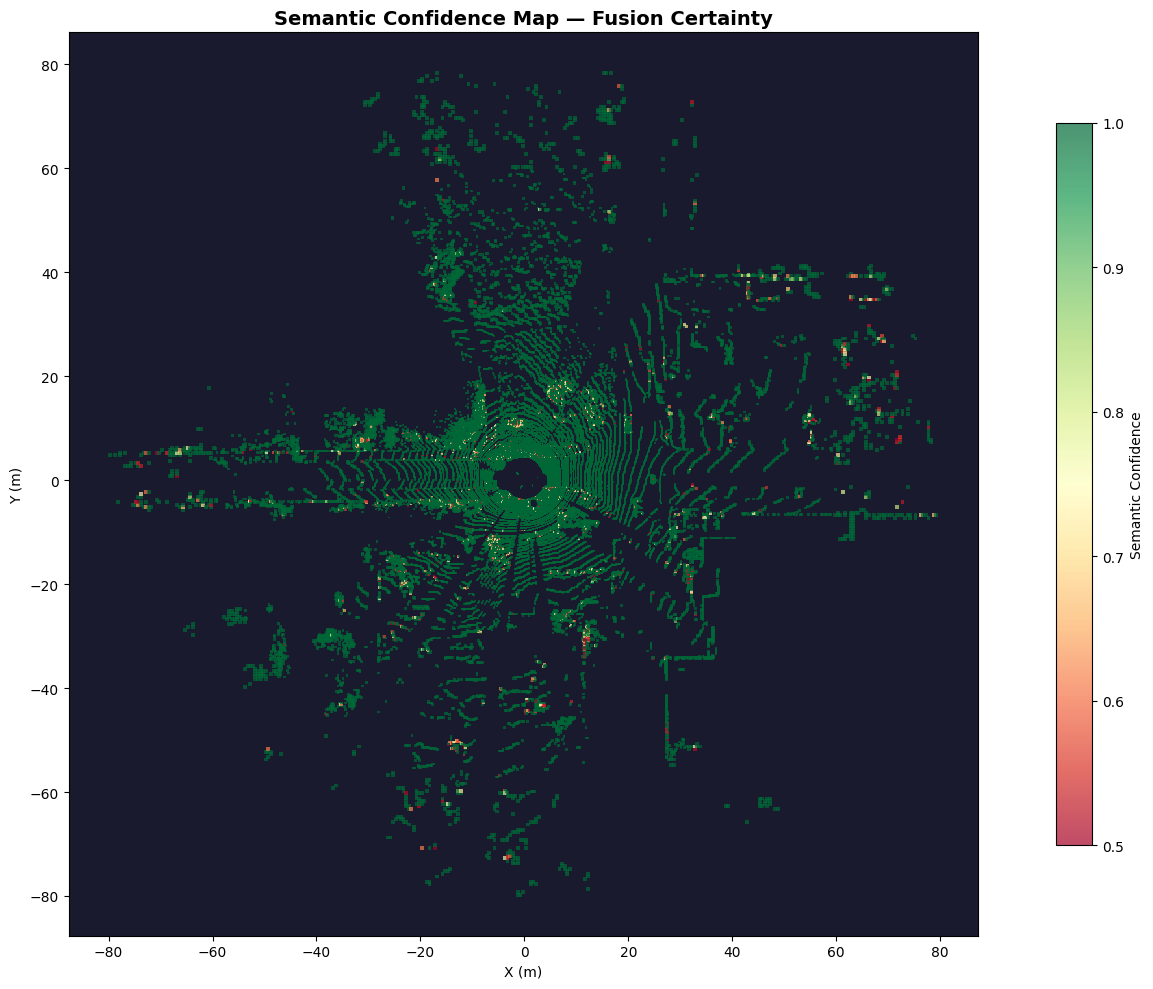

Saved: vis_15_semantic_confidence.png


In [10]:
fig, ax = plt.subplots(figsize=(16, 10))

sc = ax.scatter(
    cell_cx, cell_cy,
    c=cell_semantic_confidence,
    cmap='RdYlGn', vmin=0.5, vmax=1.0,
    s=sizes, marker='s', alpha=0.7, edgecolors='none'
)

cbar = plt.colorbar(sc, ax=ax, label="Semantic Confidence", shrink=0.8)
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_title("Semantic Confidence Map — Fusion Certainty", fontsize=14, fontweight='bold')
ax.set_aspect('equal')
ax.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig("vis_15_semantic_confidence.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: vis_15_semantic_confidence.png")

### 6.3 — Semantic Priority Map

Preview of which cells will be candidates for quadtree refinement in Phase 6.
High-priority cells (vehicles, pedestrians, walls, poles) are shown in warm colors.


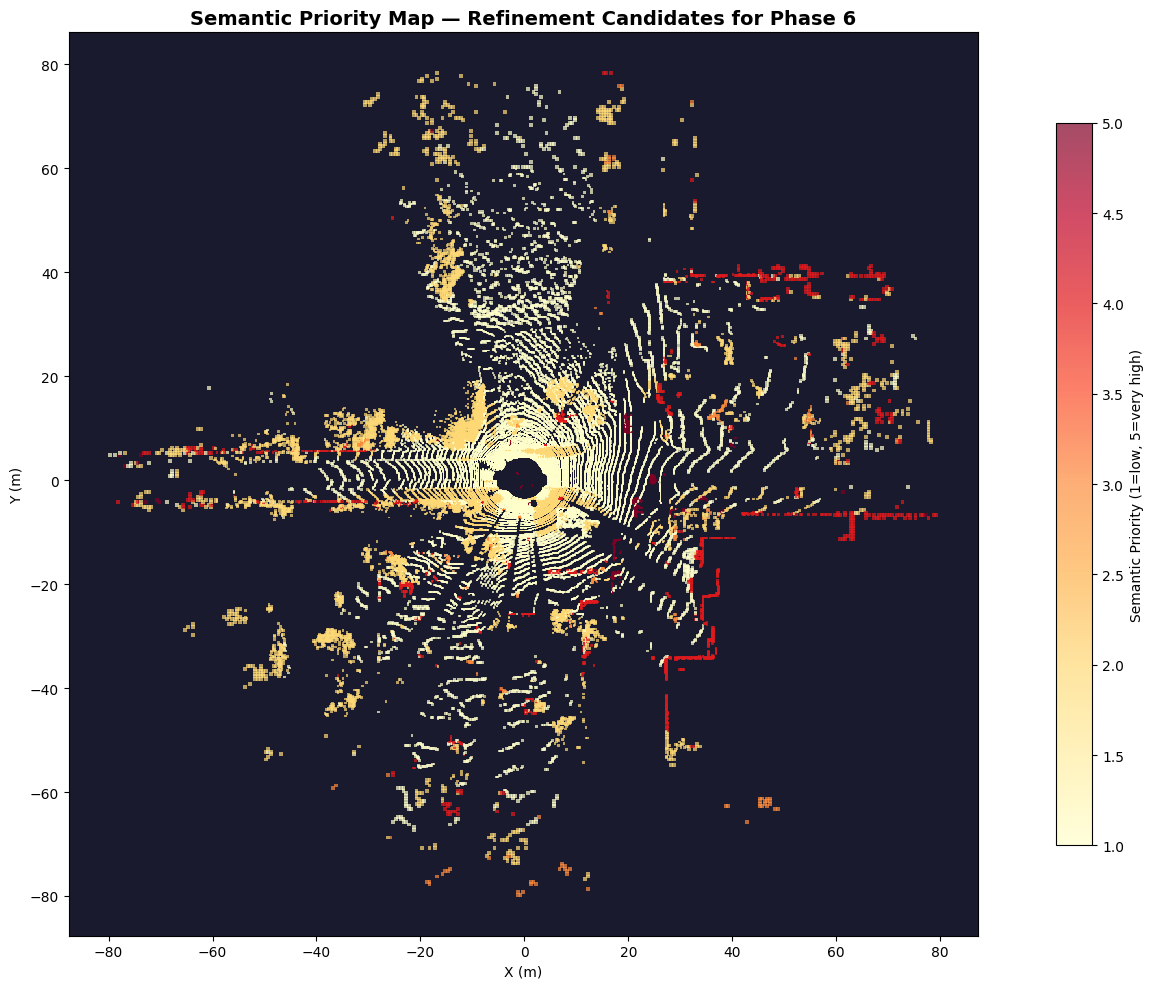

Saved: vis_16_semantic_priority.png


In [11]:
fig, ax = plt.subplots(figsize=(16, 10))

priority_cmap = plt.cm.YlOrRd
norm = mcolors.Normalize(vmin=1, vmax=5)

sc = ax.scatter(
    cell_cx, cell_cy,
    c=cell_semantic_priority,
    cmap=priority_cmap, norm=norm,
    s=sizes, marker='s', alpha=0.7, edgecolors='none'
)

cbar = plt.colorbar(sc, ax=ax, label="Semantic Priority (1=low, 5=very high)", shrink=0.8)
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_title("Semantic Priority Map — Refinement Candidates for Phase 6", fontsize=14, fontweight='bold')
ax.set_aspect('equal')
ax.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig("vis_16_semantic_priority.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: vis_16_semantic_priority.png")

### 6.4 — Class Distribution Comparison


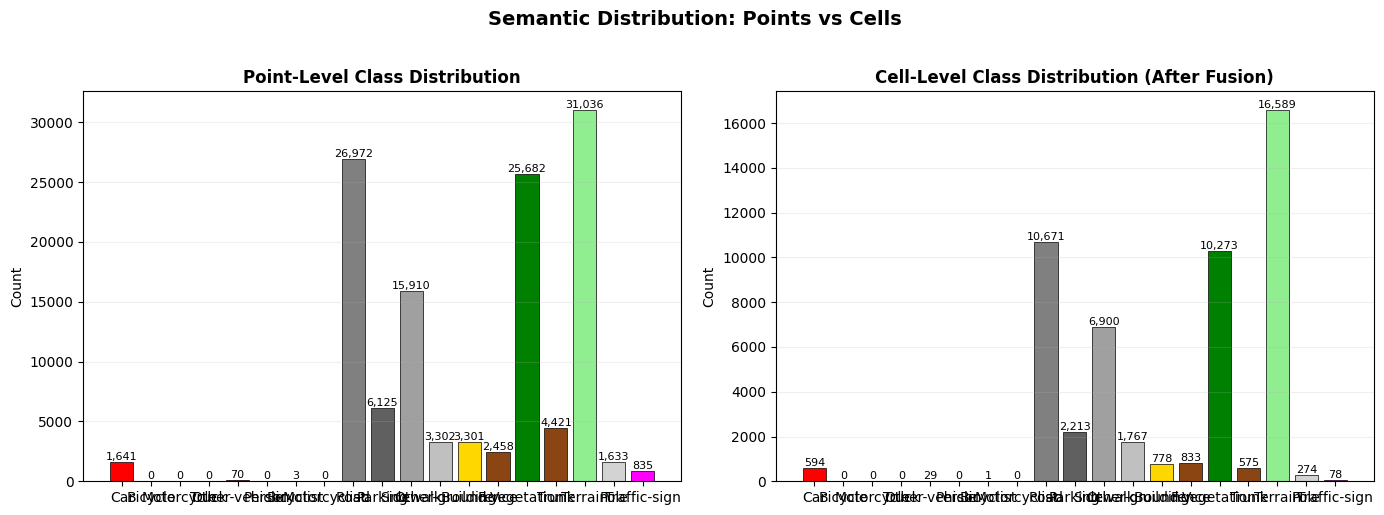

Saved: vis_17_class_distribution.png


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

class_names = [LABEL_NAMES[i] for i in range(N_CLASSES)]
colors = [CLASS_COLORS[i] for i in range(N_CLASSES)]

# Point-level distribution
point_counts = [(labels == i).sum() for i in range(N_CLASSES)]
bars1 = ax1.bar(class_names, point_counts, color=colors, edgecolor='black', linewidth=0.5)
ax1.set_ylabel("Count")
ax1.set_title("Point-Level Class Distribution", fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.2)
for bar, count in zip(bars1, point_counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{count:,}", ha='center', va='bottom', fontsize=8)

# Cell-level distribution
cell_counts = [(cell_semantic_class == i).sum() for i in range(N_CLASSES)]
bars2 = ax2.bar(class_names, cell_counts, color=colors, edgecolor='black', linewidth=0.5)
ax2.set_ylabel("Count")
ax2.set_title("Cell-Level Class Distribution (After Fusion)", fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.2)
for bar, count in zip(bars2, cell_counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{count:,}", ha='center', va='bottom', fontsize=8)

plt.suptitle("Semantic Distribution: Points vs Cells", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("vis_17_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: vis_17_class_distribution.png")

## 7. Save Output for Phase 5


In [13]:
output_file = "phase4_output.npz"

np.savez(
    output_file,
    # Pass through
    points_xyz=points_xyz,
    labels=labels,
    confidence=confidence,
    intensity=intensity,
    radial_distance=radial_distance,
    point_to_cell=point_to_cell,
    point_resolution=point_resolution,
    sorted_order=sorted_order,
    group_starts=group_starts,
    group_ends=group_ends,
    # Extended cell data (now includes semantics)
    cell_data=cell_data_extended,
    cell_columns=np.array(cell_columns_extended),
    # Semantic score matrix (useful for Phase 6 refinement)
    cell_scores=cell_scores,       # (n_cells, N_CLASSES)
    # Metadata
    grid_config=np.array(grid_config),
    metadata=np.array(metadata),
    semantic_config=np.array({
        "label_names": LABEL_NAMES,
        "class_colors": CLASS_COLORS,
        "semantic_priority": SEMANTIC_PRIORITY,
        "n_classes": N_CLASSES,
    }),
)

# ── Verify ──────────────────────────────────────────────────────
verify = np.load(output_file, allow_pickle=True)
print(f"Saved: {output_file}")
print(f"  File size: {os.path.getsize(output_file) / 1024:.1f} KB")
print(f"  Keys: {list(verify.keys())}")
print(f"\n  cell_data    : {verify['cell_data'].shape}")
print(f"  cell_columns : {list(verify['cell_columns'])}")
print(f"  cell_scores  : {verify['cell_scores'].shape}")

assert verify['cell_data'].shape == cell_data_extended.shape
assert verify['cell_scores'].shape == (n_cells, N_CLASSES)
print(f"\nPhase 4 output ready for Phase 5 (Quadtree Engine)")

Saved: phase4_output.npz
  File size: 22706.4 KB
  Keys: ['points_xyz', 'labels', 'confidence', 'intensity', 'radial_distance', 'point_to_cell', 'point_resolution', 'sorted_order', 'group_starts', 'group_ends', 'cell_data', 'cell_columns', 'cell_scores', 'grid_config', 'metadata', 'semantic_config']

  cell_data    : (51575, 15)
  cell_columns : [np.str_('x_min'), np.str_('y_min'), np.str_('x_max'), np.str_('y_max'), np.str_('resolution'), np.str_('point_count'), np.str_('elevation'), np.str_('min_height'), np.str_('max_height'), np.str_('height_variance'), np.str_('height_range'), np.str_('occupancy'), np.str_('semantic_class'), np.str_('semantic_confidence'), np.str_('semantic_priority')]
  cell_scores  : (51575, 19)

Phase 4 output ready for Phase 5 (Quadtree Engine)


## Summary

**Phase 4 Complete.** Results:

| Item | Status |
|------|--------|
| Confidence-weighted voting | Done |
| Per-cell semantic class | Done |
| Per-cell semantic confidence | Done |
| Per-cell semantic priority | Done |
| Score conservation validated | PASS |
| All cells have valid classes | PASS |
| 4 visualizations generated | Done |
| Output saved for Phase 5 | Done |

**Cell data now has 15 columns:**
```
Spatial:   x_min, y_min, x_max, y_max, resolution, point_count
Elevation: elevation, min_height, max_height, height_variance, height_range, occupancy
Semantic:  semantic_class, semantic_confidence, semantic_priority
```

**Next → Phase 5: Quadtree Engine**
- Build the hierarchical spatial structure
- Parent/child four-way subdivision
- Configurable maximum depth and minimum resolution
